In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [4]:
# image = Image.open("images/fake_1.jpg").convert("RGB")
image = Image.open("images/real/real_1.png").convert("RGB")
image_np = np.array(image)

In [5]:
print("Image shape: ", image_np.shape)
print("min pixel value: ", image_np.min())
print("max pixel value: ", image_np.max())

Image shape:  (512, 512, 3)
min pixel value:  0
max pixel value:  255


# compute the NPR map of input image

In [6]:
image_float = image_np.astype(np.float32)

half = np.array(Image.fromarray(image_np).resize(
  (image_np.shape[1] // 2, image_np.shape[0] // 2),
  Image.NEAREST
))

half_upscaled = np.array(Image.fromarray(half).resize(
  (image_np.shape[1], image_np.shape[0]),
  Image.NEAREST
))

npr_map = image_float - half_upscaled.astype(np.float32)

In [7]:
npr_display = npr_map - npr_map.min()
npr_display = npr_display / npr_display.max() * 255
npr_display = npr_display.astype(np.uint8)

In [8]:
def get_npr(image_name):
  image = Image.open(f"images/{image_name}").convert("RGB")
  image_np = np.array(image)
  
  image_float = image_np.astype(np.float32)

  half = np.array(Image.fromarray(image_np).resize(
    (image_np.shape[1] // 2, image_np.shape[0] // 2),
    Image.NEAREST
  ))

  half_upscaled = np.array(Image.fromarray(half).resize(
    (image_np.shape[1], image_np.shape[0]),
    Image.NEAREST
  ))

  npr_map = image_float - half_upscaled.astype(np.float32)
  
  npr_display = npr_map - npr_map.min()
  npr_display = npr_display / npr_display.max() * 255
  npr_display = npr_display.astype(np.uint8)
  
  fig, axes = plt.subplots(1, 2, figsize = (14, 8))

  axes[0].imshow(image_np)
  axes[0].set_title("Original Image")
  axes[0].axis("off")

  axes[1].imshow(npr_display)
  axes[1].set_title("NPR Map")
  axes[1].axis("off")

  plt.tight_layout()
  plt.show()

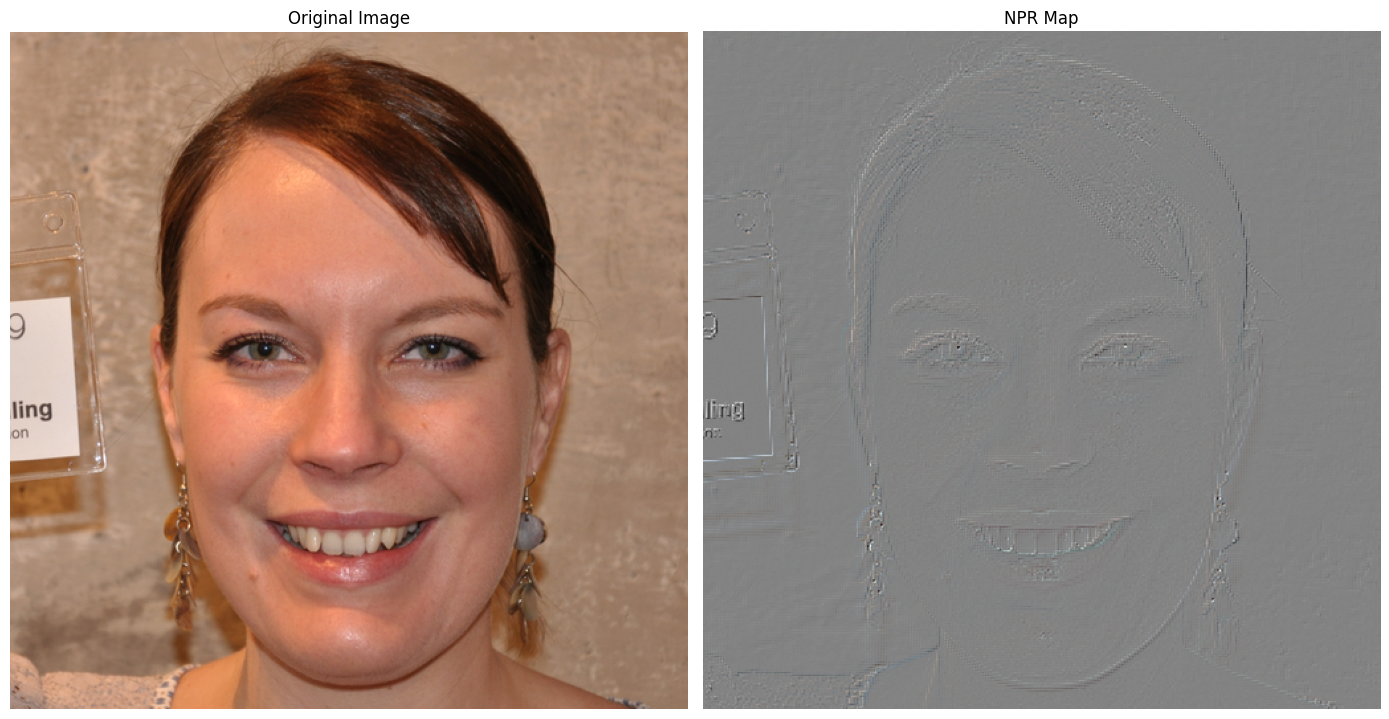

In [10]:
get_npr('real/real_1.png')

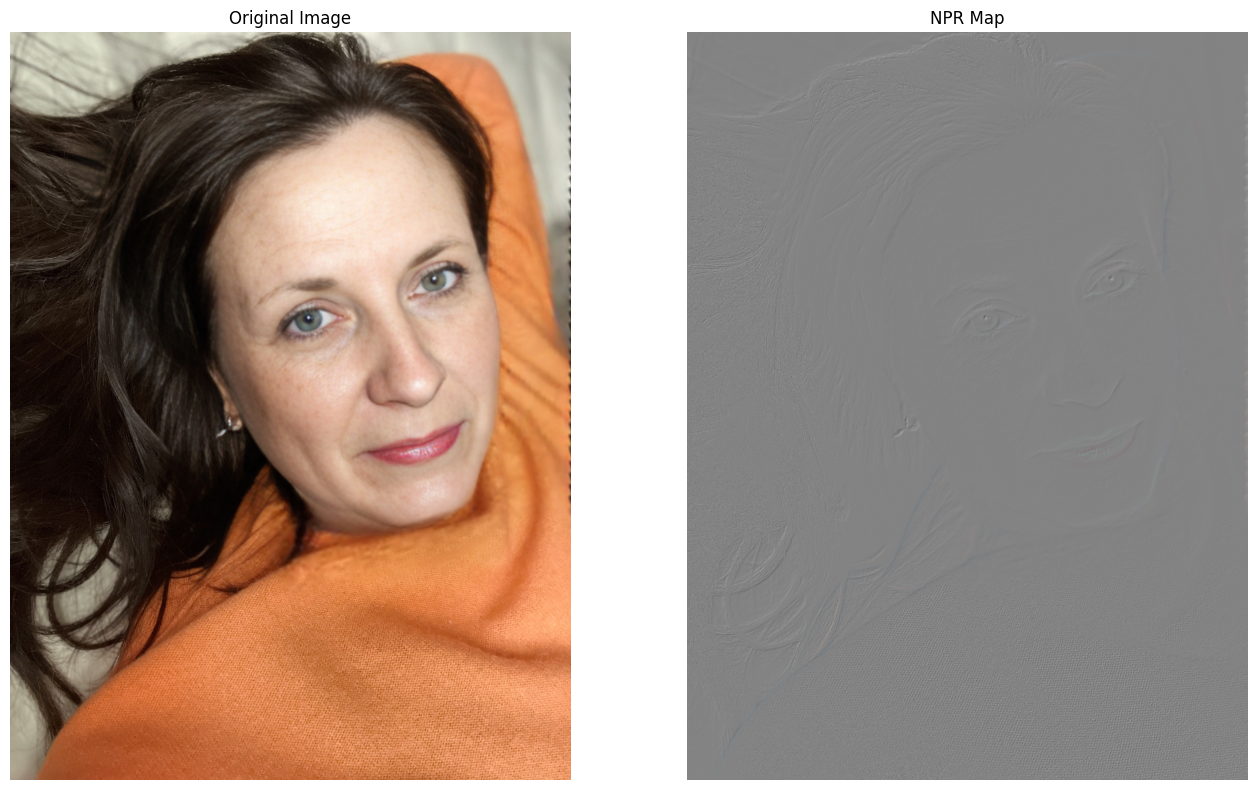

In [11]:
get_npr('fake/fake_1.jpg')